# 02 - Heat Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \alpha u_{xx}$, $\alpha = 0.01$

**IC:** $u(x,0) = \sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 32, 32, 32, 1]` | **Epochs:** 10000

**Note:** Heat equation is smooth - used as baseline to confirm AC-PINN
does not hurt performance on easy problems.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    HeatFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'heat'
LAYERS     = [2, 32, 32, 32, 1]
EPOCHS     = 10000
PDE_PARAMS = {'alpha': 0.01}
RESULTS    = '../results/heat/'
FIGURES    = '../figures/heat/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, alpha=0.01)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

HeatFDM solved in 0.2971s


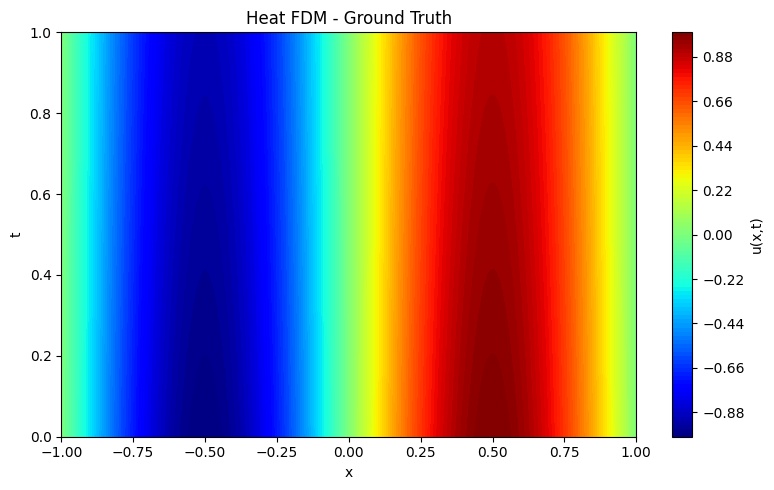

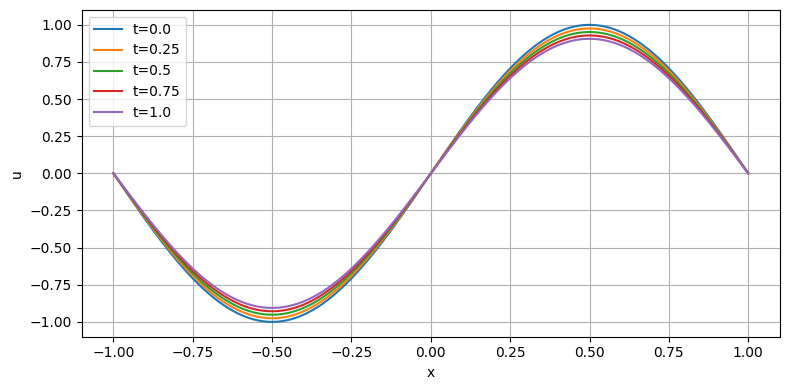

In [2]:
fdm = HeatFDM(nx=256, nt=1000, alpha=0.01)
fdm.solve()
fdm.plot_solution(title='Heat FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Heat | Vanilla Clean | Epoch     0/10000] Total: 2.404748 | IC: 0.988484 | BC: 0.521438 | PDE: 0.178965


[Heat | Vanilla Clean | Epoch  1000/10000] Total: 0.001174 | IC: 0.000260 | BC: 0.000033 | PDE: 0.000176


[Heat | Vanilla Clean | Epoch  2000/10000] Total: 0.000108 | IC: 0.000020 | BC: 0.000022 | PDE: 0.000013


[Heat | Vanilla Clean | Epoch  3000/10000] Total: 0.000058 | IC: 0.000010 | BC: 0.000016 | PDE: 0.000007


...

[Heat | Vanilla Clean | Epoch  6000/10000] Total: 0.000019 | IC: 0.000004 | BC: 0.000004 | PDE: 0.000002


[Heat | Vanilla Clean | Epoch  7000/10000] Total: 0.000015 | IC: 0.000003 | BC: 0.000003 | PDE: 0.000002


[Heat | Vanilla Clean | Epoch  8000/10000] Total: 0.000011 | IC: 0.000002 | BC: 0.000002 | PDE: 0.000001


[Heat | Vanilla Clean | Epoch  9000/10000] Total: 0.000009 | IC: 0.000001 | BC: 0.000002 | PDE: 0.000001



Training complete in 90.42s


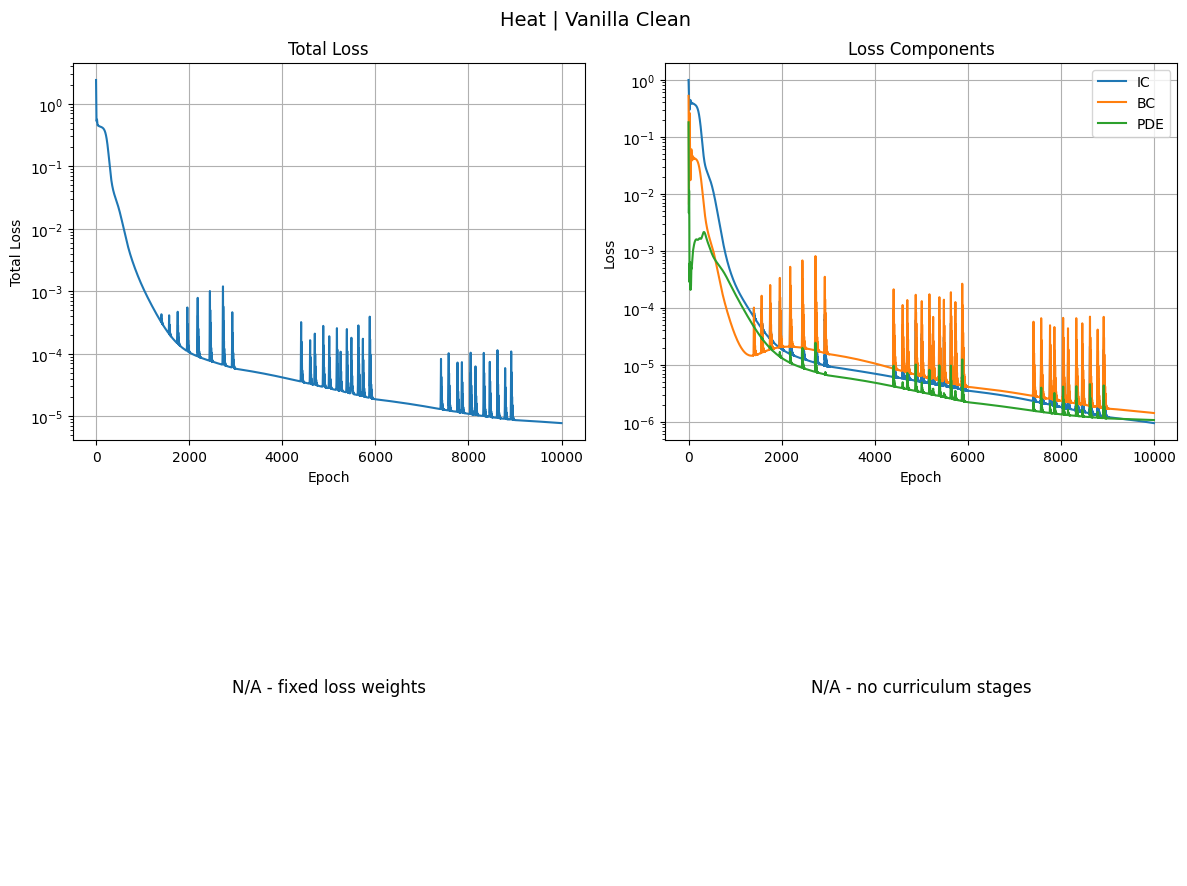

Saved: ../figures/heat/vanilla_clean_training.png
Saved: ../figures/heat/vanilla_clean_training.csv


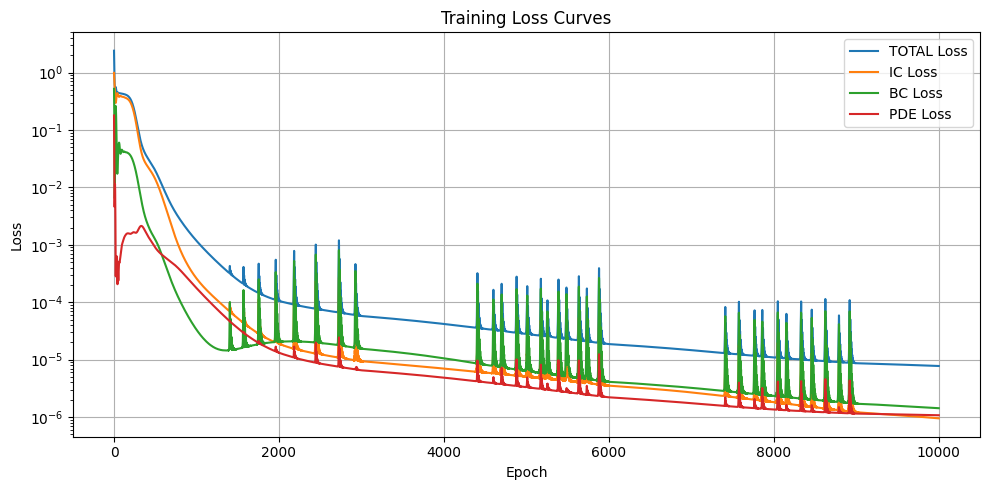

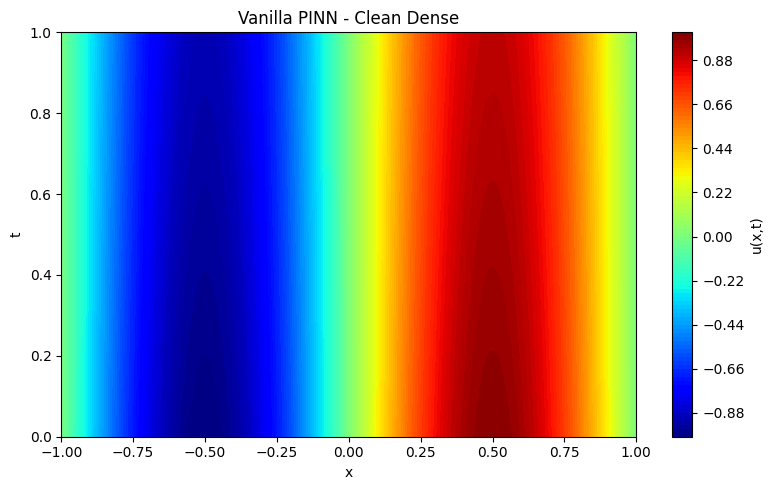

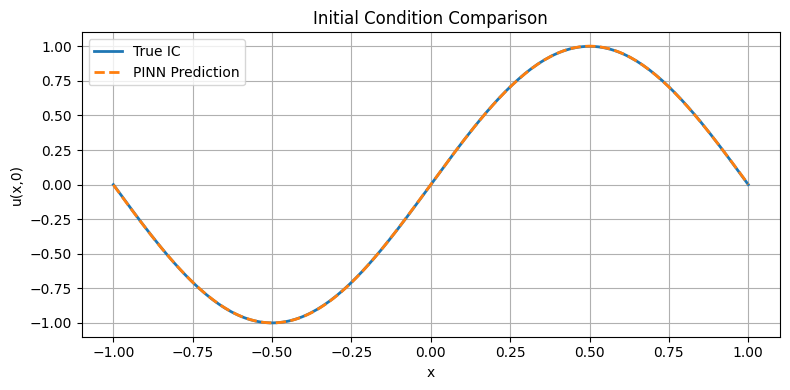

Saved: ../results/heat/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Heat | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Heat | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse

[Heat | Vanilla Noisy | Epoch     0/10000] Total: 3.381221 | IC: 0.677774 | BC: 0.354437 | PDE: 0.469802


[Heat | Vanilla Noisy | Epoch  1000/10000] Total: 0.022123 | IC: 0.006937 | BC: 0.014507 | PDE: 0.000136


[Heat | Vanilla Noisy | Epoch  2000/10000] Total: 0.019269 | IC: 0.004784 | BC: 0.014209 | PDE: 0.000055


[Heat | Vanilla Noisy | Epoch  3000/10000] Total: 0.019112 | IC: 0.004709 | BC: 0.014217 | PDE: 0.000037


[Heat | Vanilla Noisy | Epoch  4000/10000] Total: 0.019028 | IC: 0.004649 | BC: 0.014208 | PDE: 0.000034


...

[Heat | Vanilla Noisy | Epoch  6000/10000] Total: 0.018825 | IC: 0.004311 | BC: 0.014338 | PDE: 0.000035


[Heat | Vanilla Noisy | Epoch  7000/10000] Total: 0.018562 | IC: 0.004184 | BC: 0.014180 | PDE: 0.000040


[Heat | Vanilla Noisy | Epoch  8000/10000] Total: 0.018433 | IC: 0.004066 | BC: 0.014151 | PDE: 0.000043


[Heat | Vanilla Noisy | Epoch  9000/10000] Total: 0.018292 | IC: 0.003974 | BC: 0.014120 | PDE: 0.000040



Training complete in 88.94s


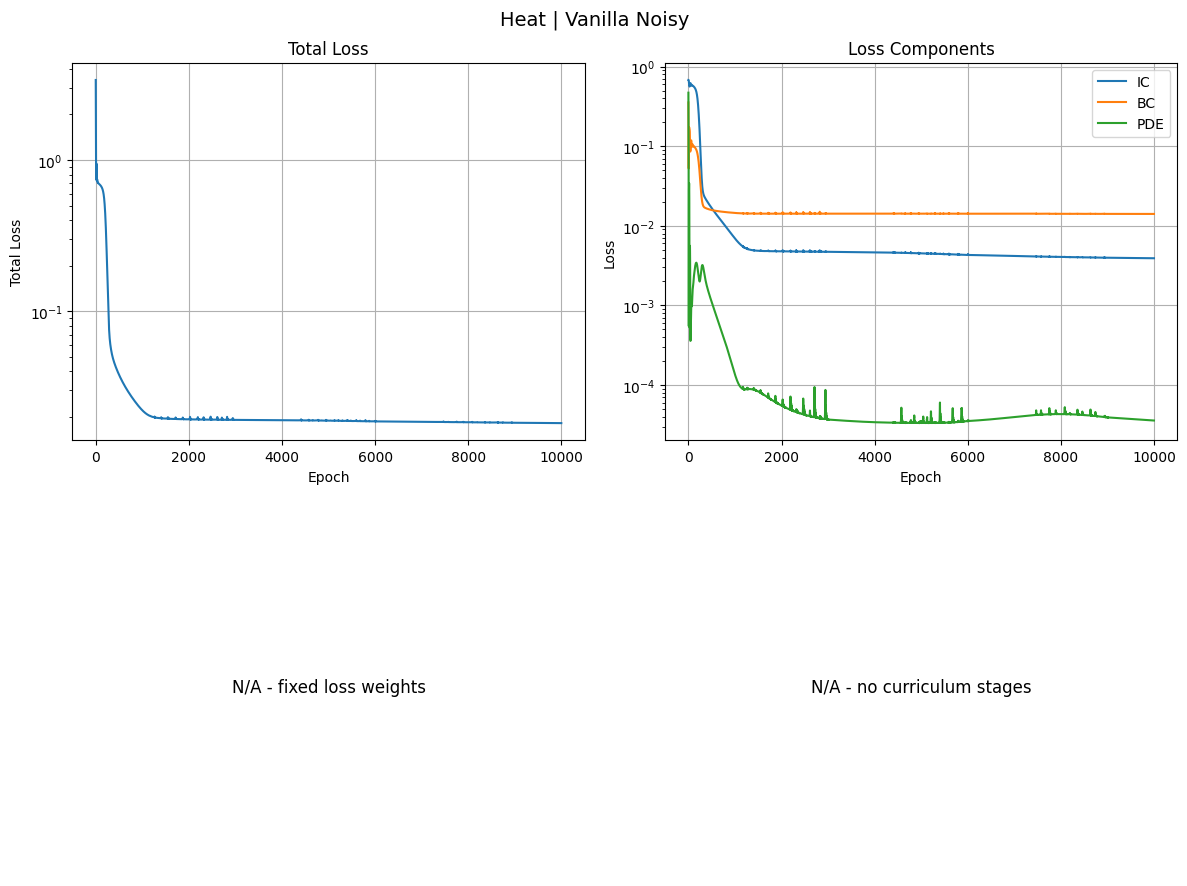

Saved: ../figures/heat/vanilla_noisy_training.png
Saved: ../figures/heat/vanilla_noisy_training.csv


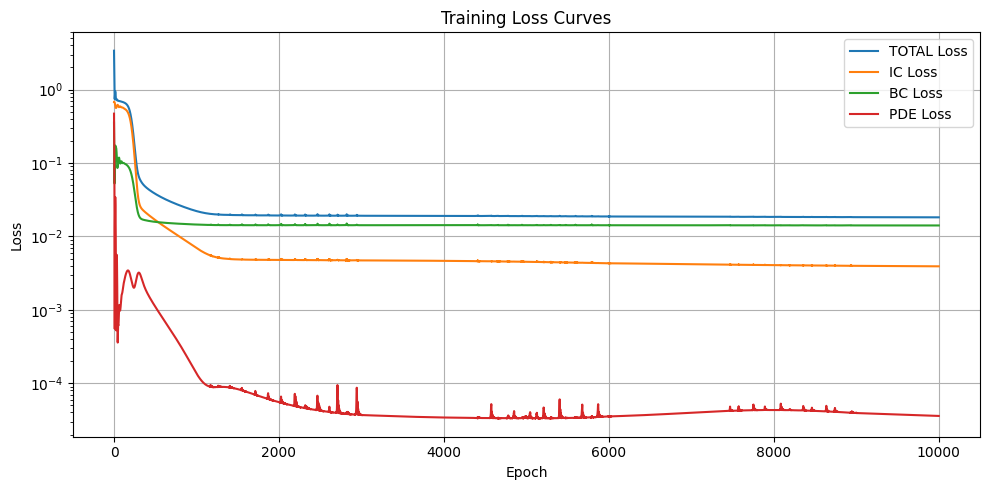

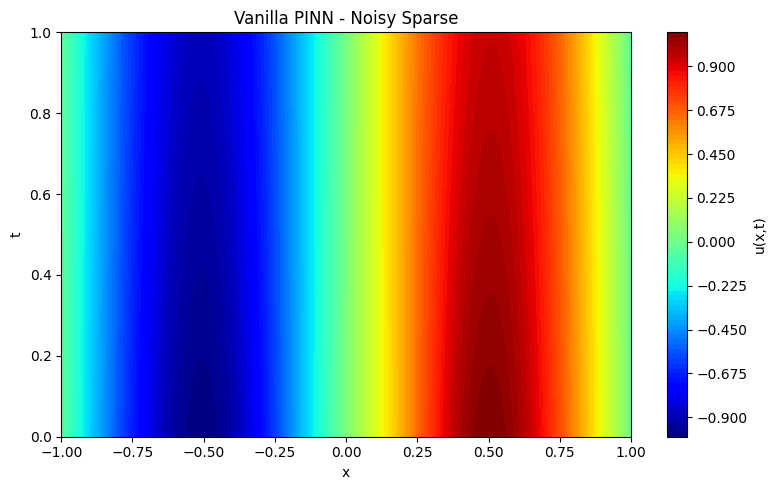

Saved: ../results/heat/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Heat | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Heat | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Heat | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.452553 | IC: 0.415686 | BC: 0.032964 | PDE: 0.000781 | lam=(1.00,1.00,5.00)


[Heat | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.000414 | IC: 0.000010 | BC: 0.000021 | PDE: 0.000029 | lam=(10.00,1.08,10.00)


[Heat | AC-PINN Clean | Epoch  2000/10000] Stage 2/4 | Total: 0.000110 | IC: 0.000010 | BC: 0.000007 | PDE: 0.000007 | lam=(1.64,2.89,10.00)


[Heat | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.000048 | IC: 0.000005 | BC: 0.000005 | PDE: 0.000002 | lam=(3.71,1.48,10.00)


[Heat | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.000037 | IC: 0.000003 | BC: 0.000003 | PDE: 0.000002 | lam=(3.79,1.39,10.00)


...

[Heat | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.000019 | IC: 0.000004 | BC: 0.000004 | PDE: 0.000009 | lam=(0.68,0.72,1.60)


[Heat | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000016 | IC: 0.000004 | BC: 0.000003 | PDE: 0.000007 | lam=(0.77,0.71,1.52)


[Heat | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.000050 | IC: 0.000005 | BC: 0.000007 | PDE: 0.000022 | lam=(0.44,0.59,1.96)


[Heat | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.000021 | IC: 0.000003 | BC: 0.000005 | PDE: 0.000010 | lam=(0.51,0.81,1.68)



AC-PINN training complete in 103.69s


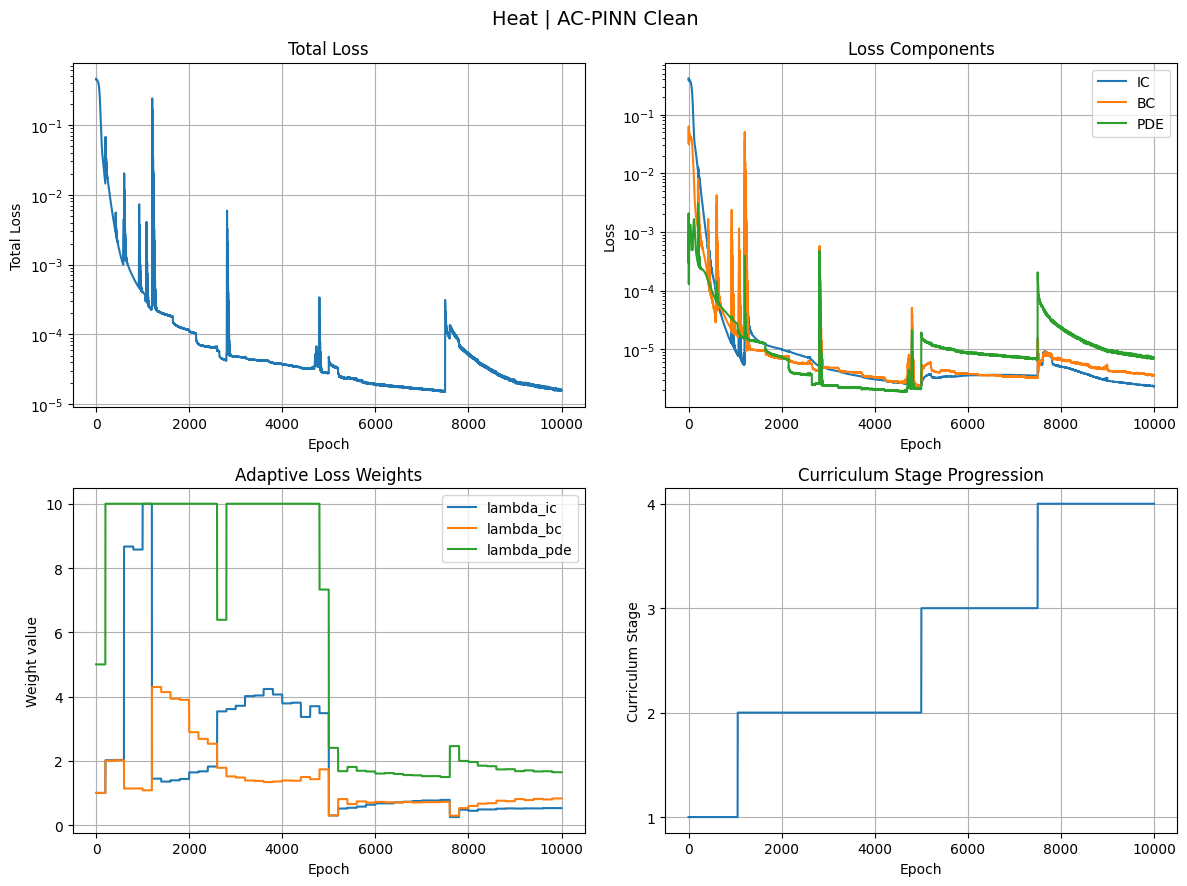

Saved: ../figures/heat/acpinn_clean_training.png
Saved: ../figures/heat/acpinn_clean_training.csv


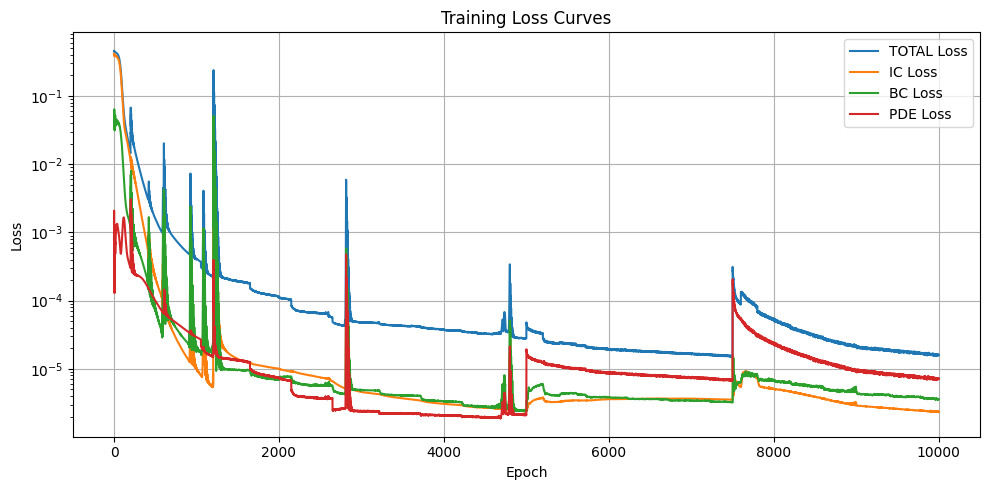

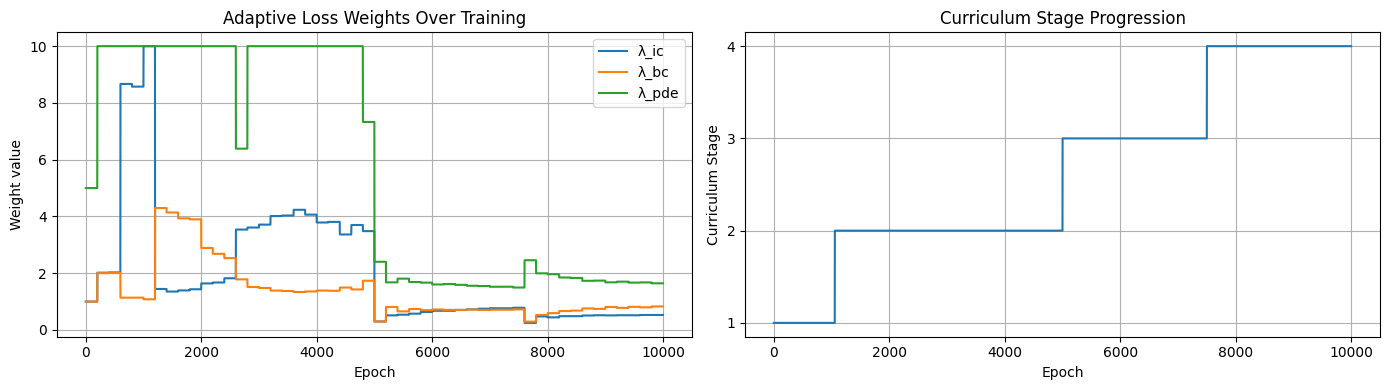

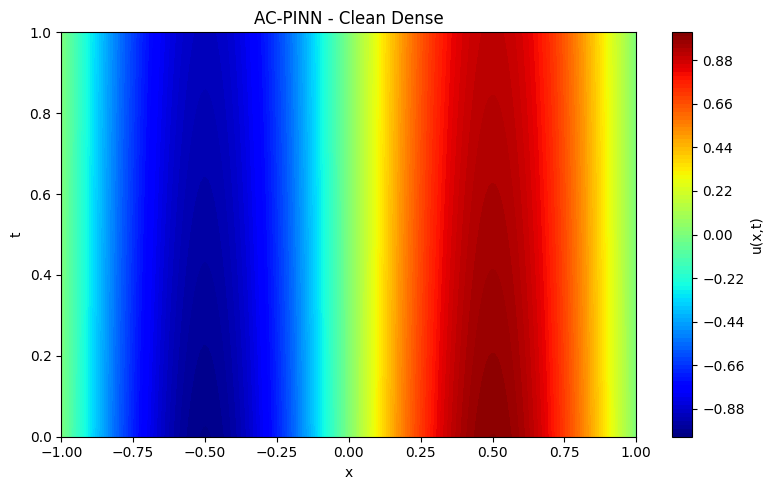

Saved: ../results/heat/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Heat | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Heat | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse

[Heat | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.836552 | IC: 0.814343 | BC: 0.019940 | PDE: 0.000454 | lam=(1.00,1.00,5.00)


[Heat | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.036710 | IC: 0.004091 | BC: 0.013920 | PDE: 0.000052 | lam=(3.80,1.48,10.00)


[Heat | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.035142 | IC: 0.003978 | BC: 0.013233 | PDE: 0.000033 | lam=(2.63,1.84,10.00)


[Heat | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.031742 | IC: 0.003880 | BC: 0.012727 | PDE: 0.000029 | lam=(2.54,1.70,10.00)


[Heat | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.044295 | IC: 0.003867 | BC: 0.012073 | PDE: 0.000032 | lam=(6.91,1.44,6.26)


...

[Heat | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.018555 | IC: 0.004238 | BC: 0.008125 | PDE: 0.001660 | lam=(0.91,1.74,0.36)


[Heat | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.017950 | IC: 0.004036 | BC: 0.007782 | PDE: 0.001315 | lam=(0.92,1.78,0.30)


[Heat | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.024210 | IC: 0.003845 | BC: 0.010852 | PDE: 0.005561 | lam=(0.57,1.61,0.82)


[Heat | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.027203 | IC: 0.003827 | BC: 0.011961 | PDE: 0.002083 | lam=(0.64,2.01,0.35)



AC-PINN training complete in 102.25s


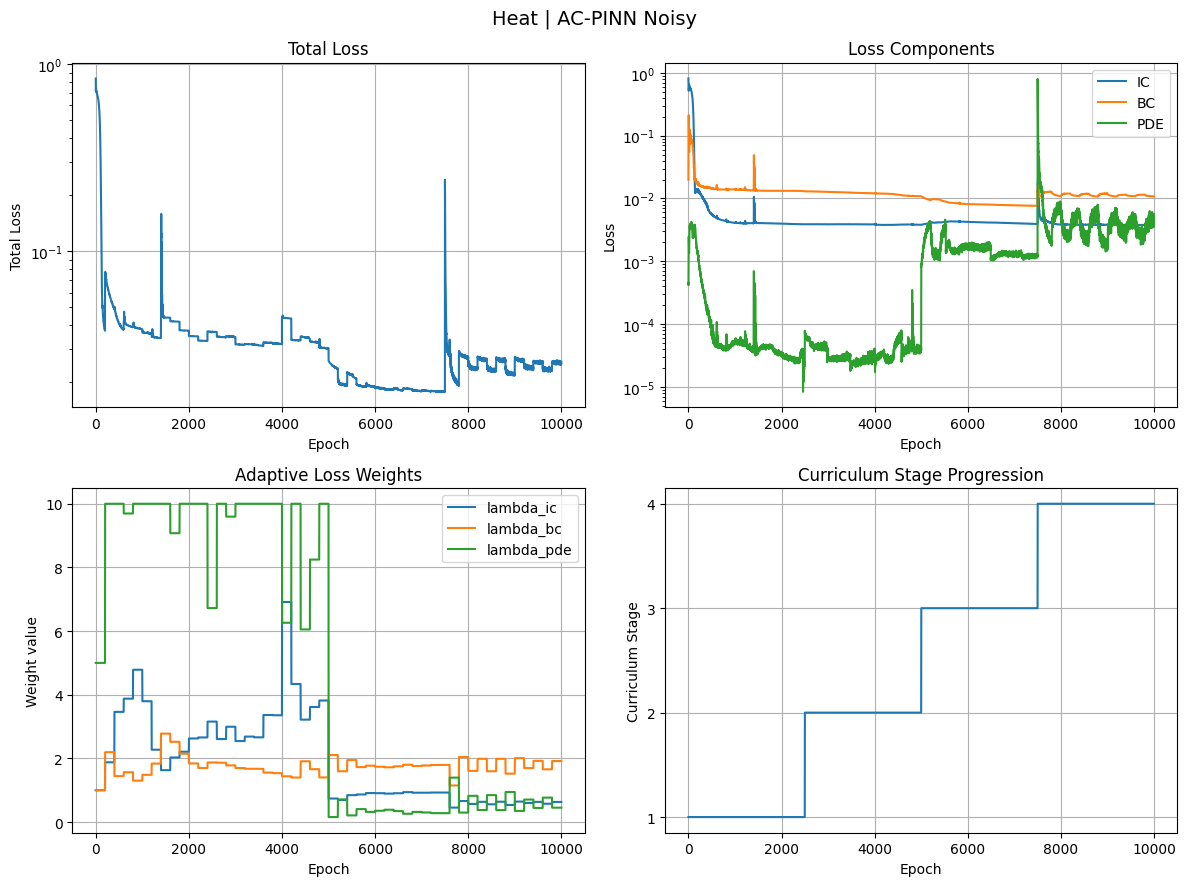

Saved: ../figures/heat/acpinn_noisy_training.png
Saved: ../figures/heat/acpinn_noisy_training.csv


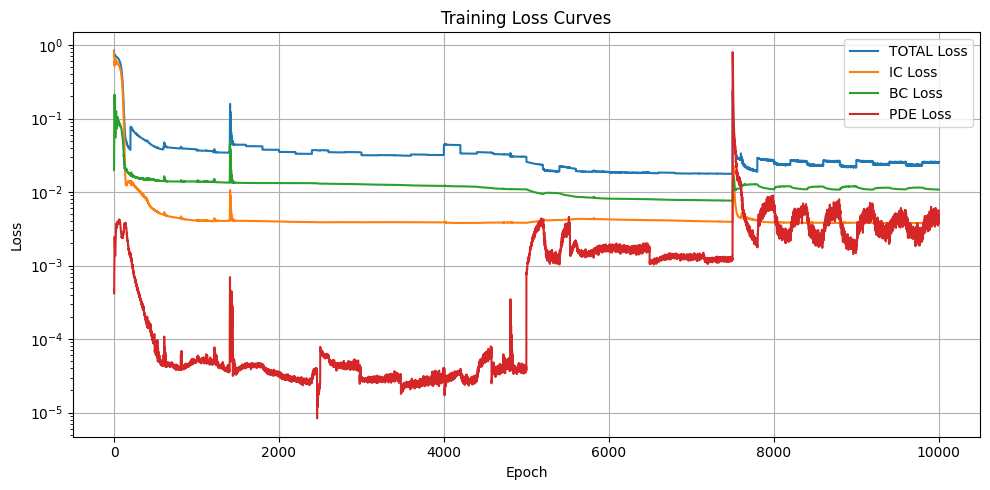

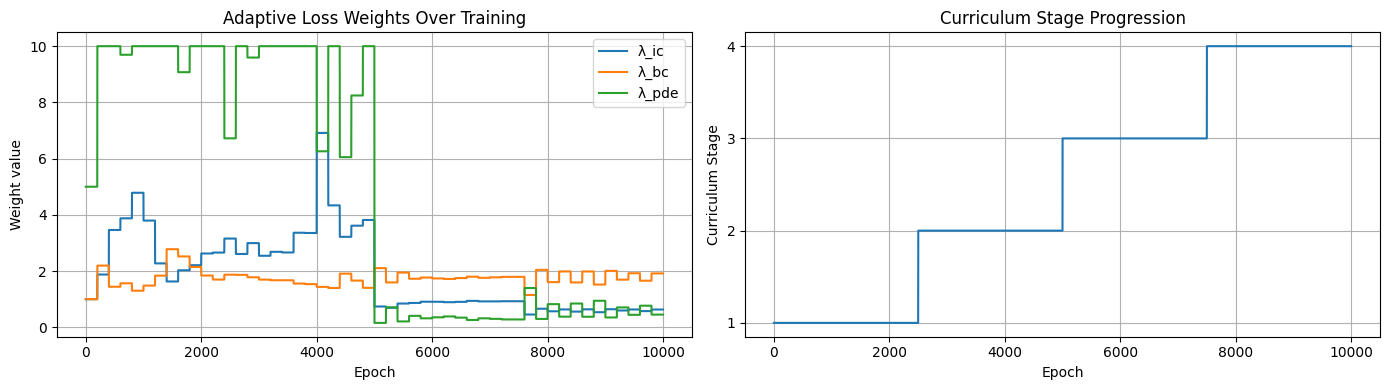

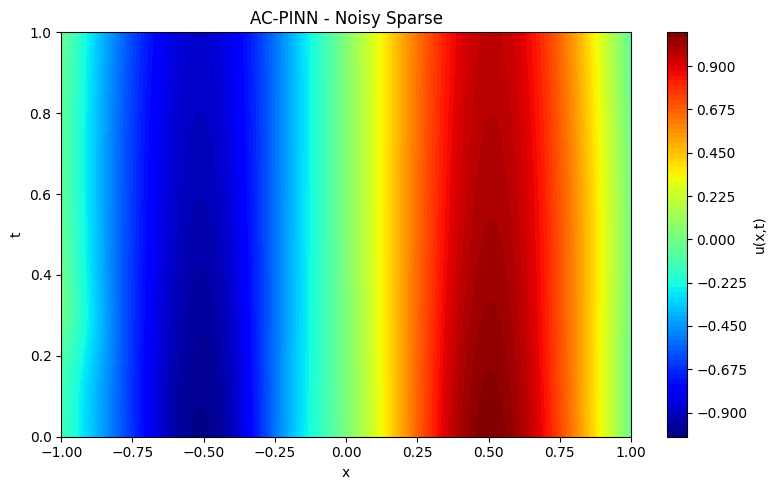

Saved: ../results/heat/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Heat | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Heat | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.000876   0.002008   0.000503   0.000589
  Vanilla (noisy)             0.058720   0.108768   0.030658   0.039473
  AC-PINN (clean)             0.001390   0.003837   0.000710   0.000934
  AC-PINN (noisy)             0.084514   0.190968   0.041048   0.056812


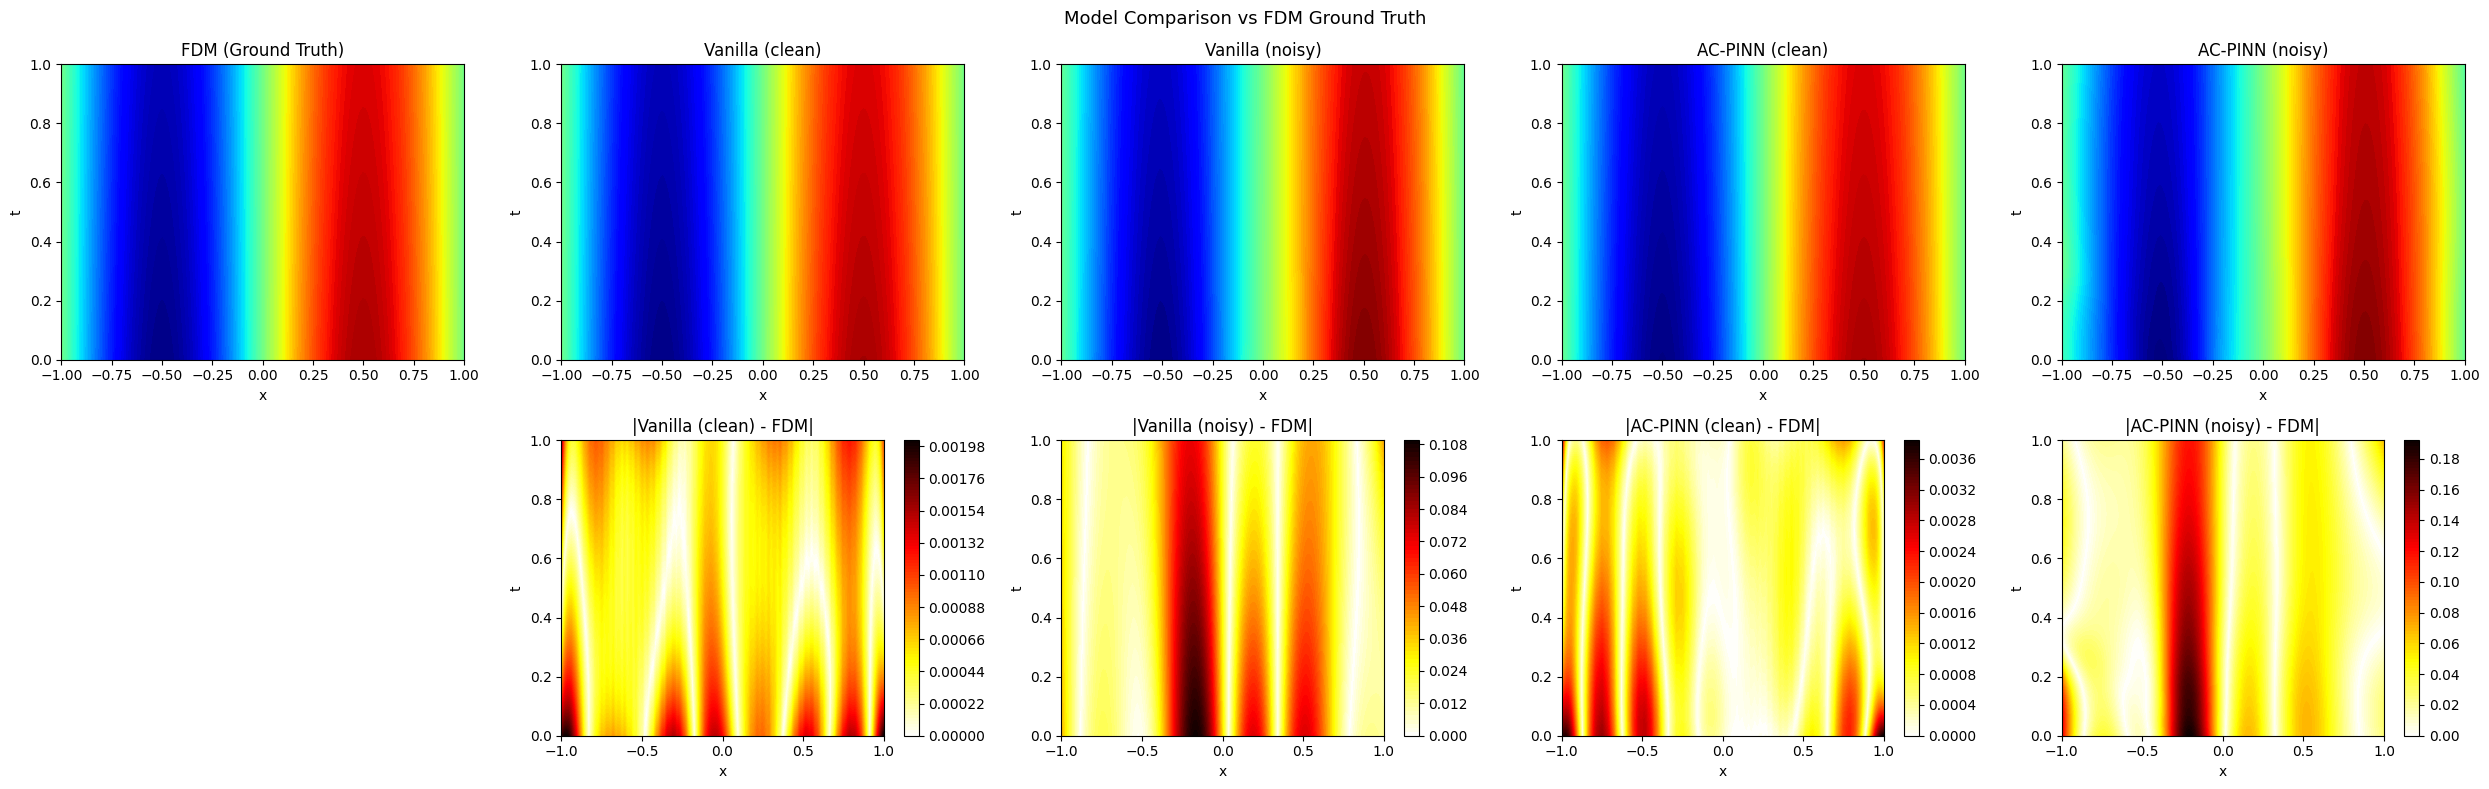

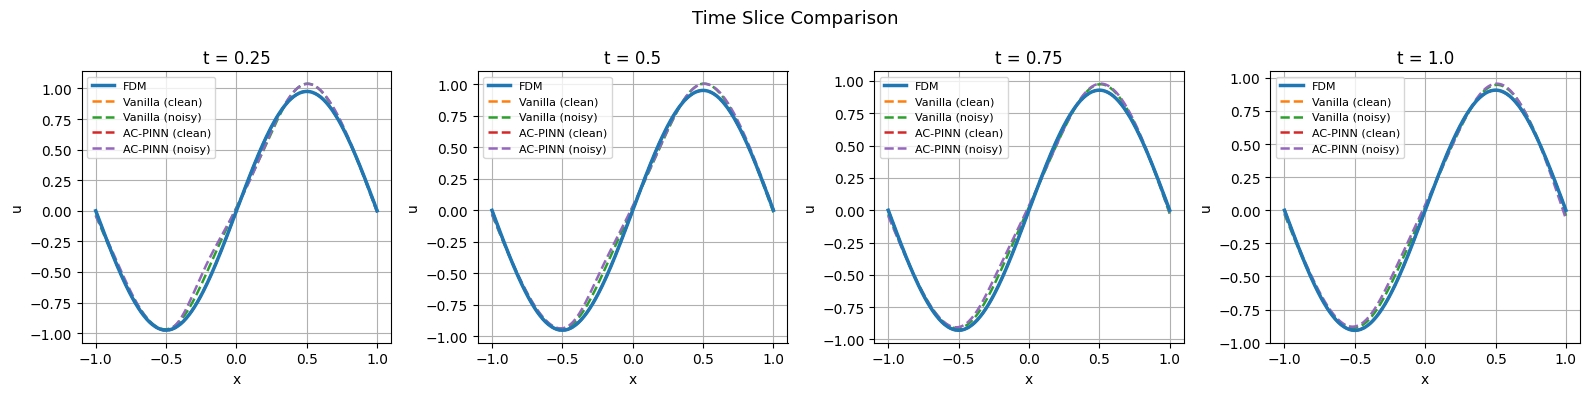

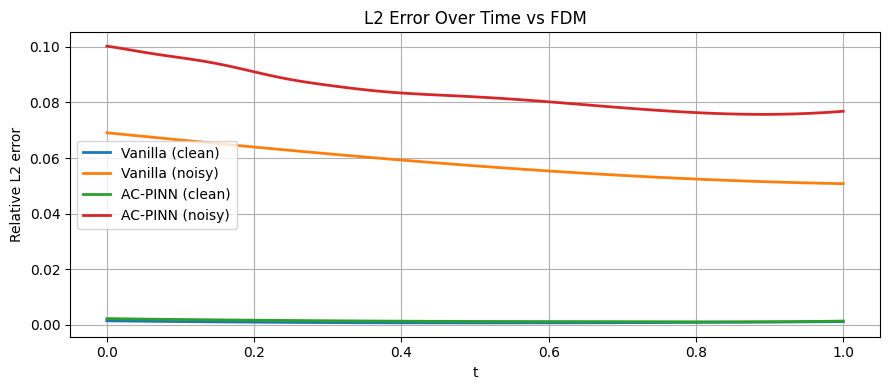

Saved: ../results/heat/benchmark_metrics.npy
Heat experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Heat experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')


--- ε=0.05 ---
[Epoch     0/5000] Total: 1.190666 | IC: 0.748023 | BC: 0.294075 | PDE: 0.029713


[Epoch  2500/5000] Total: 0.005397 | IC: 0.002225 | BC: 0.003080 | PDE: 0.000018



Training complete in 44.90s
[Epoch     0/5000] Stage 1/4 | Total: 0.621857 | IC: 0.521271 | BC: 0.038111 | PDE: 0.012495 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.007752 | IC: 0.002053 | BC: 0.003007 | PDE: 0.000077 | lam=(1.20,1.75,0.10)



AC-PINN training complete in 51.45s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.014359   0.027436   0.008016   0.009653
  AC-PINN ε=0.05              0.020644   0.036696   0.010825   0.013877

--- ε=0.1 ---
[Epoch     0/5000] Total: 1.733232 | IC: 0.431732 | BC: 0.138541 | PDE: 0.232592


...


AC-PINN training complete in 51.75s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.031914   0.062874   0.017035   0.021453
  AC-PINN ε=0.1               0.038039   0.062349   0.020836   0.025571

--- ε=0.2 ---
[Epoch     0/5000] Total: 0.485230 | IC: 0.305845 | BC: 0.166760 | PDE: 0.002525


[Epoch  2500/5000] Total: 0.111357 | IC: 0.020156 | BC: 0.090472 | PDE: 0.000146



Training complete in 44.73s
[Epoch     0/5000] Stage 1/4 | Total: 1.652980 | IC: 0.518126 | BC: 0.310105 | PDE: 0.164950 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.256894 | IC: 0.023015 | BC: 0.083374 | PDE: 0.000813 | lam=(1.70,2.51,10.00)



AC-PINN training complete in 51.17s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.190705   0.476678   0.099101   0.128195
  AC-PINN ε=0.2               0.151356   0.253273   0.082575   0.101745
Saved: ../results/heat/noise_study_metrics.npy
